In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchdiffeq #负责数值积分Euler、RK4等把时间 0 的噪声逐步“演化”成时间 1 的数据样本。
import torch.nn.functional as F

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


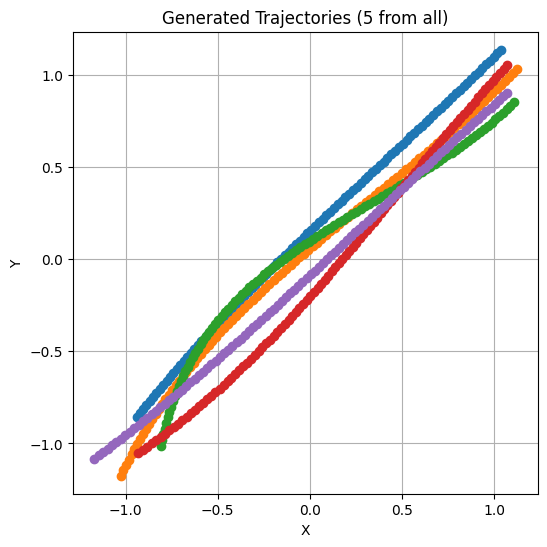

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

def sample_point_in_circle(center, radius): #在一个以 center 为圆心radius 为半径的圆里随机采样一个点
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):#生成贝塞尔曲线
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t  

# ---------------------------

#通过调整控制点 P1 和 P2 的扰动强度来定义不同类型的轨迹形态起点端弯终点端弯双端对称弯
baseline_start = np.array([-1, -1])
baseline_end   = np.array([ 1,  1])
radius = 0.2 

dominant_endpoint = "start"

if dominant_endpoint == "start":
    perturbation_scale_P1 = 0.7  
    perturbation_scale_P2 = 0.01 
elif dominant_endpoint == "end":
    perturbation_scale_P1 = 0.1  
    perturbation_scale_P2 = 0.3 
else:

    perturbation_scale_P1 = perturbation_scale_P2 = 0.2


num_trajectories = 8000 
trajectories = []

for i in range(num_trajectories):

    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0 #主方向，从起点指向终点
    perp_vector = np.array([-base_vector[1], base_vector[0]]) # 垂直方向向量 V=（-y,x）
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8) #向量长度标准化（归一化）
  
    P1 = P0 + base_vector / 3.0
    P2 = P0 + 2 * base_vector / 3.0
    
    #扰动 生成随机数沿着垂直方向扰动

    P1 = P1 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P2 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    

    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)

    curve = curve.T #B_t 100*2 转置后 2*100
    trajectories.append(curve) #[curve_0, curve_1] 循环后list 8000个

trajectories = np.array(trajectories) #[8000, 2, 100]

# ---------------------------

num_plots = 5
#8000随机选择5个轨迹
indices = np.random.choice(len(trajectories), size=num_plots, replace=False)

plt.figure(figsize=(6, 6))
for idx in indices:
    traj = trajectories[idx]
    plt.plot(traj[0], traj[1], marker='o', linestyle='-')
plt.title("Generated Trajectories (5 from all)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.show()

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModelWrapper  


class TrajectoryDataset(Dataset):
    def __init__(self, trajectories): #初始化
        self.trajectories = trajectories
        print(trajectories.shape) #8000*2*100 # numpy 或 torch，[N, 2, 100]

    def __len__(self):
        return len(self.trajectories) #N 8000

    def __getitem__(self, idx):
        traj = self.trajectories[idx] # 8000*2*100 [2, 100]
        return torch.tensor(traj, dtype=torch.float32) #返回一个张量变成float32
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class FCFlattenUpsampler(nn.Module):
    def __init__(self, input_shape=(2, 100), output_shape=(1, 28, 28)): #对应了二维张量轨迹xy 100步
        super().__init__()
        in_dim = input_shape[0] * input_shape[1] #2*100=200
        out_dim = output_shape[0] * output_shape[1] * output_shape[2] #1*28*28=784
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 512), #输入维度 2*100=200 输出维度 512
            Mish(),
            nn.Linear(512, 512),
            Mish(),
            nn.Linear(512, out_dim)
        )
        self.norm = nn.LayerNorm(out_dim)
        self.output_shape = output_shape

    def forward(self, x):
        x = x.view(x.size(0), -1) #展平 1*200 -1 表示展平所有维度 自动推算剩余维度
        x = self.fc(x) #512
        x = self.norm(x) #512 层归一化 使其均值为 0 方差为 1
        x = x.view(-1, *self.output_shape) #1*1*784
        return x

class FCDownsampler(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), output_shape=(2, 100)):
        super().__init__()
        in_dim = input_shape[0] * input_shape[1] * input_shape[2]
        out_dim = output_shape[0] * output_shape[1]
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 512),
            Mish(),
            nn.Linear(512, 512),
            Mish(),
            nn.Linear(512, out_dim)
        )
        self.output_shape = output_shape

    def forward(self, x):
        x = x.view(x.size(0), -1) #展平 1*784 -1 表示展平所有维度 自动推算剩余维度
        x = self.fc(x)   
        return x.view(x.size(0), *self.output_shape) #1*2*100   
    
class FlowMatchingModel(ModelWrapper):
    def __init__(self, upsampler, model, downsampler):
        super().__init__(model)
        self.upsampler = upsampler
        self.downsampler = downsampler
        
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        #x 1*2*100 t 1*1
        # t: 时间步 (batch_size, 1)
        # x: 输入图像 (batch_size, C, H, W)
        # y: 条件标签 (batch_size,)

        x_img = self.upsampler(x)
        
        dummy_label = torch.zeros((x.shape[0],), dtype=torch.long, device=x.device)
        
        v_img = self.model(t, x_img, dummy_label)
        
        v_traj = self.downsampler(v_img)
        
        return v_traj

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

upsampler = FCFlattenUpsampler().to(device)
downsampler = FCDownsampler().to(device)
unet_model = UNetModelWrapper(
    dim=(1, 28, 28),
    num_channels=64,
    num_res_blocks=2,
    num_classes=10,
    class_cond=True
).to(device)

fm_model = FlowMatchingModel(upsampler, unet_model, downsampler)

optimizer = torch.optim.Adam(
    list(unet_model.parameters()) +
    list(upsampler.parameters()) +
    list(downsampler.parameters()),
    lr=3e-4
)

path = AffinePath(scheduler=CondOTScheduler())

batch_size = 64
train_dataset = TrajectoryDataset(trajectories)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

n_epochs = 150
loss_history = []
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

for epoch in range(n_epochs):
    for batch_traj in train_loader:
        optimizer.zero_grad()
        
        x1_traj = batch_traj.to(device) 
        x0_traj = torch.randn_like(x1_traj)  
        
        t = torch.rand(x1_traj.shape[0]).to(device)
        
        path_sample = path.sample(t=t, x_0=x0_traj, x_1=x1_traj)
        
        vt_pred = fm_model(path_sample.x_t, path_sample.t)
        
        flow_loss = torch.mean((vt_pred - path_sample.dx_t) ** 2)
        
        x1_img = upsampler(x1_traj)
        recon_traj = downsampler(x1_img)
        recon_loss = torch.mean((recon_traj - x1_traj) ** 2)
        
        loss = flow_loss + 1.0 * recon_loss
        
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    
    scheduler.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item():.6f}")

ModuleNotFoundError: No module named 'fmtorch'

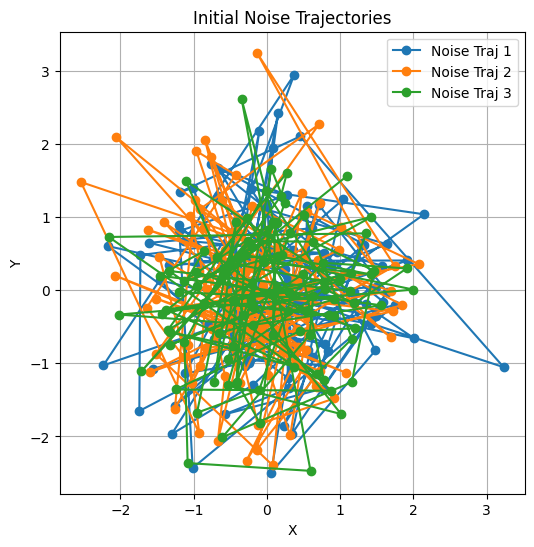

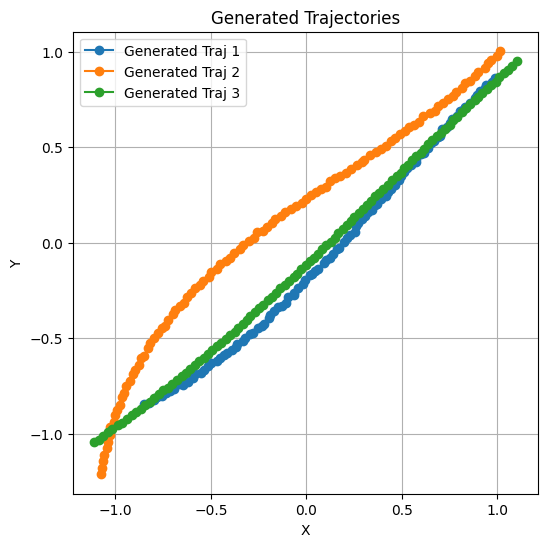

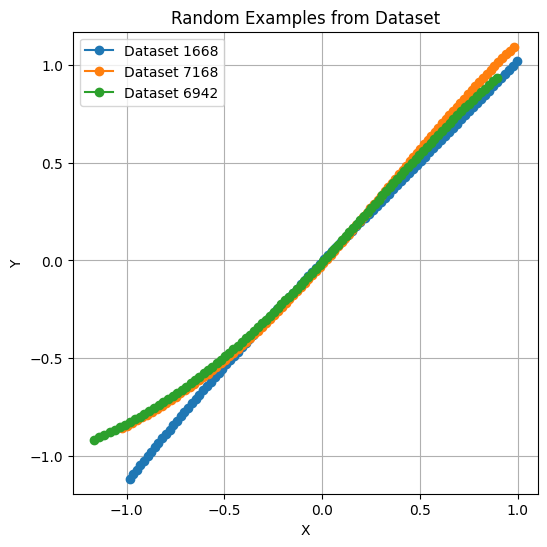

In [ ]:
solver = ODESolver(velocity_model=fm_model)

with torch.no_grad():
    noise_trajs = torch.randn((3, 2, 100), device=device)

noise_trajs_np = noise_trajs.cpu().numpy()
plt.figure(figsize=(6, 6))
for i in range(3):
    plt.plot(noise_trajs_np[i, 0], noise_trajs_np[i, 1], 
             marker='o', label=f"Noise Traj {i+1}")
plt.title("Initial Noise Trajectories")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()

time_grid = torch.tensor([0.0, 1.0], device=device)

with torch.no_grad():
    generated_trajs = solver.sample(
        x_init=noise_trajs,
        time_grid=time_grid,
        method='dopri5',
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False
    )

generated_trajs_np = generated_trajs.cpu().numpy()
plt.figure(figsize=(6, 6))
for i in range(3):
    plt.plot(generated_trajs_np[i, 0], generated_trajs_np[i, 1], 
             marker='o', label=f"Generated Traj {i+1}")
plt.title("Generated Trajectories")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()

plt.figure(figsize=(6, 6))
rand_indices = np.random.choice(trajectories.shape[0], size=3, replace=False)
for idx in rand_indices:
    plt.plot(trajectories[idx, 0], trajectories[idx, 1], 
             marker='o', linestyle='-', label=f"Dataset {idx}")
plt.title("Random Examples from Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()